# 01 · GARCH foundations
## Predicting the Left Tail

How much can we learn about downside risk from a volatility model?

This is our working notebook for **Part 1, Days 1–2**. The explanations, code, and saved outputs document our Part 1 walkthrough. Run the cells in order in a fresh kernel to recreate the calculations. The accompanying article is available in `article/01_garch_foundations.md`.

Our scope: inspect the daily data, understand returns and squared returns, fit ARCH, GARCH, GARCH-t, and GJR-GARCH-t, then compare their responses to positive and negative shocks. Five-day forecasting and machine learning come later. We pause for review at the end of Part 1.

### 1. Get oriented

Select the project's `.venv/bin/python` as the notebook kernel. It uses Python 3.11.14. The notebook lives in `notebooks/`; the source code, data, and tests sit one directory above it.

We'll start with imports and locate the project directory. Nothing here downloads data or fits a model.

In [9]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
print(ROOT)
print(sys.version)

<project-root>
3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.6.3.2)]


### 2. Where should we get the data?

For this first experiment:

- **SPY:** Yahoo Finance through `yfinance`. We explicitly select **Adj Close**, which accounts for splits and dividends. That avoids treating a dividend adjustment as a market loss.
- **VIX:** Yahoo Finance's `^VIX` closing values.
- **VIX3M:** [Cboe's historical CSV](https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX3M_History.csv). Yahoo returned only one observation, so the supporting downloader used this source instead.

A local snapshot has already been downloaded into `data/raw/`. Its manifest records source details, dates, missingness, and checksums. We'll inspect that snapshot rather than fetch fresh data every time we run a cell.

VIX and VIX3M describe volatility implied by options over different horizons. We collect them now for later experiments; the Part 1 models use SPY returns only.

[The yfinance download options](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html).

**Before running the next cell on a fresh checkout:** follow the [README setup and data instructions](../README.md#prepare-the-data-and-run-part-1). After setting up and activating the project environment, run this in a terminal from the repository root:

```sh
python scripts/download_data.py
```

This writes the files to `data/raw/`; the next cell only reads them. An existing snapshot is verified against its local manifest and reused. A fresh download can differ from our original sample because providers can revise historical data; the frozen-snapshot distribution and reference-verification workflow is still pending. Do not use `--refresh` unless intentionally replacing your local inputs. The downloader can omit VIX3M if unavailable, but the later VIX/VIX3M audit requires it—inspect the manifest's `optional_failures` if its file is missing.


In [10]:
# Load the saved SPY data. First inspect the available columns and dates.
spy_data = pd.read_csv(
    ROOT / 'data/raw/SPY_source.csv',
    index_col='Date',
    parse_dates=True,
)
spy_data.head()

,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
1993-01-29,24.113262,0.0,43.93750,0.0,43.96875,43.75000,43.96875,0.0,1003200
1993-02-01,24.284773,0.0,44.25000,0.0,44.25000,43.96875,43.96875,0.0,480500
1993-02-02,24.336220,0.0,44.34375,0.0,44.37500,44.12500,44.21875,0.0,201300
1993-02-03,24.593470,0.0,44.81250,0.0,44.84375,44.37500,44.40625,0.0,529400
1993-02-04,24.696373,0.0,45.00000,0.0,45.09375,44.46875,44.96875,0.0,531500


Before calculating anything, let's check the sample. What are the first and last dates? Are dates ordered and unique? Are prices missing or nonpositive?

Missing source rows and missing trading days are different checks. The current audit compares index coverage with the supplied SPY dates; it does not independently verify every exchange session. We should keep that limitation visible.

VIX3M begins later. We won't discard early SPY history just to force all three series to start together.

In [11]:
# Together: inspect SPY coverage and missing adjusted prices.
display(f'SPY_DATA.isna(): {spy_data.isna().sum()}')
print("First date:", spy_data.index.min())
print("Last date:", spy_data.index.max())
print("Rows:", len(spy_data))
print("Dates ordered:", spy_data.index.is_monotonic_increasing)
print("Dates unique:", spy_data.index.is_unique)
# Then open data/raw/manifest.json to compare VIX and VIX3M coverage.
usable_sample = spy_data.dropna(subset=["Adj Close"])
# Report the exact usable sample rather than guessing from the date range.
print("Usable sample first date:", usable_sample.index.min())
print("Usable sample last date:", usable_sample.index.max())
print("Usable sample rows:", len(usable_sample))
print("Usable sample dates ordered:", usable_sample.index.is_monotonic_increasing)
print("Usable sample dates unique:", usable_sample.index.is_unique)
import json
manifest = json.loads((ROOT / "data/raw/manifest.json").read_text())
display(pd.DataFrame(manifest["audit"]).T)


'SPY_DATA.isna(): Adj Close        0\nCapital Gains    0\nClose            0\nDividends        0\nHigh             0\nLow              0\nOpen             0\nStock Splits     0\nVolume           0\ndtype: int64'

First date: 1993-01-29 00:00:00
Last date: 2026-09-15 00:00:00
Rows: 8464
Dates ordered: True
Dates unique: True
Usable sample first date: 1993-01-29 00:00:00
Usable sample last date: 2026-09-15 00:00:00
Usable sample rows: 8464
Usable sample dates ordered: True
Usable sample dates unique: True


,rows,usable,missing_in_source_rows,first_usable,last_usable,missing_on_SPY_dates,usable_daily_returns
SPY,8464,8464,0,1993-01-29,2026-09-15,0,8463
VIX,8792,8485,307,1993-01-04,2026-09-15,0,NaN
VIX3M,4273,4273,0,2009-09-18,2026-09-15,4191,NaN


### 2a. Are any trading sessions missing?

A row can be absent entirely without producing a missing value. We compare our dates with `exchange_calendars`, an independent implementation of exchange schedules that includes holidays and recorded exceptional closures. Early-close days still count as trading sessions.

**Calendar assumption:** we use `XNYS`, the NYSE session schedule. In this package, NYSE Arca (`ARCX`) is an alias for that schedule. This is our U.S. equity-session reference for SPY, not an independently verified record of every venue-specific historical event. Any mismatch needs investigation against the source and exchange records.

The check uses the explicit study window **1993-01-29 through 2026-09-15**, rather than inferring endpoints from the available rows. This lets it detect missing observations at either end too. It makes no claim about dates outside that window.

`expected.difference(observed)` finds expected sessions missing from the data; reversing the comparison finds supplied dates outside the calendar. Duplicate dates are checked separately because set comparisons ignore repetition. We also count expected sessions with a missing adjusted close.

Nothing is filled or removed. Calendar agreement establishes date coverage relative to this reference, not the accuracy of every price.

**Question:** if a date is missing, would filling its price with the previous close preserve the meaning of a one-day return?

[Calendar documentation](https://github.com/gerrymanoim/exchange_calendars).

**Answer:** carrying the previous price forward invents a zero return for the missing session and shifts its unknown movement into the next observed return. That does not recover the true daily returns.

In [12]:
import exchange_calendars as xcals

# Fixed window for this downloaded snapshot; dates are daily session labels.
study_start = pd.Timestamp("1993-01-29")
study_end = pd.Timestamp("2026-09-15")
observed_dates = pd.DatetimeIndex(spy_data.index)
assert not observed_dates.hasnans, "Investigate invalid dates first."
assert observed_dates.tz is None, "Convert to exchange-local date labels before comparing."
assert (observed_dates == observed_dates.normalize()).all(), "Expected daily date labels."

calendar = xcals.get_calendar("XNYS", start=study_start, end=study_end)
expected_dates = calendar.sessions_in_range(study_start, study_end).tz_localize(None)
missing_dates = expected_dates.difference(observed_dates)
within_window = observed_dates[(observed_dates >= study_start) & (observed_dates <= study_end)]
unexpected_dates = within_window.difference(expected_dates)
outside_window = observed_dates[(observed_dates < study_start) | (observed_dates > study_end)]
duplicate_dates = observed_dates[observed_dates.duplicated()].unique()

print("Calendar package version:", xcals.__version__)
print("Expected sessions:", len(expected_dates))
print("Observed unique dates in window:", within_window.nunique())
print("Dates ordered:", observed_dates.is_monotonic_increasing)
for label, dates in [
    ("Missing trading sessions", missing_dates),
    ("Unexpected dates inside window", unexpected_dates),
    ("Rows outside study window", outside_window),
    ("Duplicate dates", duplicate_dates),
]:
    print(f"{label}: {len(dates)}")
    if len(dates):
        display(dates.to_frame(index=False, name="Date"))

if observed_dates.is_unique:
    # Reindex only for inspection: absent sessions become NaN, never filled.
    missing_prices = spy_data["Adj Close"].reindex(expected_dates).isna()
    print("Expected sessions without an adjusted close:", int(missing_prices.sum()))
else:
    print("Resolve duplicate dates before checking price availability.")


Calendar package version: 4.13.2
Expected sessions: 8464
Observed unique dates in window: 8464
Dates ordered: True
Missing trading sessions: 0
Unexpected dates inside window: 0
Rows outside study window: 0
Duplicate dates: 0
Expected sessions without an adjusted close: 0


### 2b. Check VIX and VIX3M coverage and alignment

The same two questions apply to the volatility indexes: **is a date absent, or is its row present with a missing value?** We check the `Close` column because that is the value we will use. Missing values in unrelated columns should not discard a usable close.

**Calendar assumption / practical proxy:** we use the NYSE session schedule as a reference for U.S. equity trading days. For these Cboe indexes, this is an alignment check, not a definitive audit of Cboe's historical publication calendar. A mismatch is a reason to investigate, not automatically a bad row. A proxy is a substitute reference used when the exact reference has not been independently established.

VIX is checked over our SPY study window. The saved Cboe VIX3M history begins **2009-09-18**; earlier dates are labeled **before snapshot coverage**, not missing observations inside that history. This source boundary is not a claim about when the index was first created. We keep the end fixed at **2026-09-15**.

The first table describes the source rows inside each coverage window. The second separates absent expected rows from present rows with missing closes. The final table checks both indexes on SPY dates and reports the available overlap. No values are filled, and no rows are removed from `spy_data`.

**Question:** if a source includes a holiday row whose close is missing, should that count as a missing SPY-session feature?

**Answer:** a null holiday row is not a missing feature on a SPY trading session. The relevant comparison is with expected trading dates. We still report that extra source row so the distinction is visible.

In [13]:
# Run the imports, SPY loading cell, and Section 2a first.
vix_data = pd.read_csv(ROOT / "data/raw/VIX_source.csv", index_col="Date", parse_dates=True)
vix3m_data = pd.read_csv(ROOT / "data/raw/VIX3M_source.csv", index_col="Date", parse_dates=True)
index_inputs = {
    "VIX": (vix_data, study_start),
    "VIX3M": (vix3m_data, pd.Timestamp("2009-09-18")),
}
source_rows, calendar_rows, alignment_rows = [], [], []
index_closes = {}
spy_dates = pd.DatetimeIndex(spy_data.index)
assert spy_dates.is_unique and not spy_dates.hasnans, "Resolve SPY date issues first."
spy_dates = spy_dates[(spy_dates >= study_start) & (spy_dates <= study_end)]

for name, (frame, coverage_start) in index_inputs.items():
    dates = pd.DatetimeIndex(frame.index)
    assert not dates.hasnans and dates.tz is None, f"Inspect {name} date labels."
    assert (dates == dates.normalize()).all(), f"Expected daily labels for {name}."
    duplicate_dates = dates[dates.duplicated()].unique()
    if len(duplicate_dates):
        display(duplicate_dates.to_frame(index=False, name=f"{name} duplicate dates"))
        raise ValueError(f"Resolve {name} duplicate dates before alignment.")

    close = frame["Close"]
    in_window = close.loc[(dates >= coverage_start) & (dates <= study_end)]
    expected = calendar.sessions_in_range(coverage_start, study_end).tz_localize(None)
    absent_rows = expected.difference(in_window.index)
    present_expected = expected.intersection(in_window.index)
    null_close_dates = present_expected[in_window.reindex(present_expected).isna()]
    extra_dates = in_window.index.difference(expected)
    source_rows.append({
        "series": name, "source first row": dates.min(), "source last row": dates.max(),
        "ordered": dates.is_monotonic_increasing, "rows in coverage window": len(in_window),
        "nonmissing closes in window": int(in_window.notna().sum()),
        "null closes in window": int(in_window.isna().sum()),
        "nonpositive closes": int((in_window <= 0).sum()),
        "infinite closes": int(np.isinf(in_window.to_numpy(dtype=float)).sum()),
    })
    calendar_rows.append({
        "series": name, "coverage start": coverage_start, "coverage end": study_end,
        "expected equity sessions": len(expected), "absent rows": len(absent_rows),
        "present rows with null close": len(null_close_dates),
        "rows outside equity calendar": len(extra_dates),
    })
    for label, issue_dates in [("absent expected rows", absent_rows),
                               ("null closes on expected rows", null_close_dates),
                               ("rows outside equity calendar", extra_dates)]:
        if len(issue_dates):
            print(f"{name}: {label}")
            display(issue_dates.to_frame(index=False, name="Date"))

    within_coverage = spy_dates[spy_dates >= coverage_start]
    aligned = close.reindex(within_coverage)
    valid = aligned.notna() & np.isfinite(aligned) & (aligned > 0)
    alignment_rows.append({
        "series": name, "SPY dates before snapshot coverage": int((spy_dates < coverage_start).sum()),
        "SPY dates in coverage": len(within_coverage),
        "absent rows on SPY dates": len(within_coverage.difference(dates)),
        "SPY dates without a finite positive close": int((~valid).sum()),
    })
    index_closes[name] = close.reindex(spy_dates).where(spy_dates >= coverage_start)

print("Source coverage and values")
display(pd.DataFrame(source_rows).set_index("series"))
print("Equity-calendar reference check")
display(pd.DataFrame(calendar_rows).set_index("series"))
print("Availability on SPY dates")
display(pd.DataFrame(alignment_rows).set_index("series"))

# Availability only: this does not choose the eventual modeling sample.
feature_availability = pd.DataFrame(index_closes, index=spy_dates)
valid_both = (feature_availability.notna() & np.isfinite(feature_availability)
              & (feature_availability > 0)).all(axis=1)
common_dates = spy_dates[valid_both.to_numpy()]
print("SPY dates with valid VIX and VIX3M closes:", len(common_dates))
print("Overlap first/last:", common_dates.min(), common_dates.max())
# Date alignment alone does not prove a close was available at our prediction time.


VIX: rows outside equity calendar


,Date
0,1993-02-15
1,1993-04-09
2,1993-05-31
3,1993-07-05
4,1993-09-06
...,...
304,2026-04-03
305,2026-05-25
306,2026-06-19
307,2026-07-03


Source coverage and values


,source first row,source last row,ordered,rows in coverage window,nonmissing closes in window,null closes in window,nonpositive closes,infinite closes
series,,,,,,,,
VIX,1993-01-04,2026-09-15,True,8773,8466,307,0,0
VIX3M,2009-09-18,2026-09-15,True,4273,4273,0,0,0


Equity-calendar reference check


,coverage start,coverage end,expected equity sessions,absent rows,present rows with null close,rows outside equity calendar
series,,,,,,
VIX,1993-01-29,2026-09-15,8464,0,0,309
VIX3M,2009-09-18,2026-09-15,4273,0,0,0


Availability on SPY dates


,SPY dates before snapshot coverage,SPY dates in coverage,absent rows on SPY dates,SPY dates without a finite positive close
series,,,,
VIX,0,8464,0,0
VIX3M,4191,4273,0,0


SPY dates with valid VIX and VIX3M closes: 4273
Overlap first/last: 2009-09-18 00:00:00 2026-09-15 00:00:00


### 3. Calculate a daily return

We'll use **simple returns**:

$$r_t = \frac{P_t}{P_{t-1}} - 1.$$

If a price moves from 100 to 110, the return is 0.10, or 10%. What happens when it then falls from 110 to 99?

Let's calculate that small example before using SPY. The first observation has no previous price. Missing prices should stay missing, so we'll use `pct_change(fill_method=None)` rather than filling them.

In [14]:
toy_prices = pd.Series([100.0, 110.0, 99.0])
toy_returns = toy_prices.pct_change(fill_method=None).dropna()
print("Toy returns:", toy_returns)
np.testing.assert_allclose(toy_returns, [0.10, -0.10])
print("Compounded return:", (1 + toy_returns).prod() - 1)

from left_tail.data import daily_returns
# Missing sessions must be investigated before interpreting row-to-row returns.
assert len(missing_dates) == 0 and len(unexpected_dates) == 0
assert spy_data.index.is_unique and spy_data.index.is_monotonic_increasing
assert spy_data.index.equals(expected_dates), "Resolve study-window/date differences first."
spy_returns_with_initial_na = daily_returns(spy_data["Adj Close"])
assert spy_returns_with_initial_na.iloc[1:].notna().all(), "Investigate missing prices."
spy_returns = spy_returns_with_initial_na.iloc[1:]
display(spy_returns.head())

Toy returns: 1    0.1
2   -0.1
dtype: float64
Compounded return: -0.009999999999999898


Date
1993-02-01    0.007113
1993-02-02    0.002118
1993-02-03    0.010571
1993-02-04    0.004184
1993-02-05   -0.000695
Name: return, dtype: float64

**Review of our toy returns:** your calculation is correct: `110 / 100 - 1 = 0.10` and `99 / 110 - 1 = -0.10`. These are decimal returns, so 0.10 means 10%.

`fill_method=None` explicitly prevents missing-price filling. Dropping the first undefined return is fine in this complete toy example. With real data, inspect missing prices and absent sessions before dropping missing returns, or we might hide a gap.

The later ±4% / ±2% example is named `toy_shocks` so it does not replace `toy_returns`.

**Question:** after +10% and −10%, we end at 99 instead of 100. Why don't the two percentages cancel in the final price?

**Answer:** the gain is 10% of 100, while the loss is 10% of 110. Compounding gives $100(1.10)(0.90)=99$. More generally, $(1+a)(1-a)-1=-a^2$, an exact identity. Reversing the order gives the same terminal value. Both paths also have downside variance $(-0.10)^2=0.01$: this target does not retain the order of returns within its window.

### 4. Why square returns?

Positive and negative returns can cancel in a sum. Squaring removes the sign and puts more weight on larger moves: a 4% move contributes four times as much as a 2% move.

Absolute values also prevent cancellation. Squaring is useful here because it connects the calculation to variance.

Try the returns below. How do the signed sum, absolute sum, and squared sum differ?

**Answer:** the signed sum is 0, the absolute sum is 0.12, and the squared sum is 0.004. The signed sum is not a compounded return. Squaring removes direction and emphasizes large moves. The function is differentiable everywhere without assuming normality. Different distributions can share a variance, and extreme observations can dominate squared measures. Population variance calculations require a finite second moment; a finite sample does not establish that condition.

In [15]:
toy_shocks = pd.Series([0.04, -0.04, 0.02, -0.02])
display(pd.Series({
    "signed sum": toy_shocks.sum(),
    "absolute sum": toy_shocks.abs().sum(),
    "squared sum": toy_shocks.pow(2).sum(),
}))
np.testing.assert_allclose([toy_shocks.sum(), toy_shocks.abs().sum(), toy_shocks.pow(2).sum()],
                           [0.0, 0.12, 0.004])

signed sum      0.000
absolute sum    0.120
squared sum     0.004
dtype: float64

### 5. Are we assuming the expected return is zero?

Variance measures distance from the mean, while raw squared returns measure distance from zero:

$$\operatorname{Var}(r)=E[(r-\mu)^2],$$
$$E[r^2]=\operatorname{Var}(r)+\mu^2.$$

Here $\mu=E[r]$ is the expected return. Treating the mean squared return as variance uses a zero-mean assumption or approximation. We can inspect the size of that difference instead of assuming it away.

For a finite-sample demonstration, use `var(ddof=0)` so both quantities divide by the same observation count. A sample mean is an estimate, not a known future expected return.

For GARCH, we'll estimate a constant mean. The squared inputs are **shocks around that mean**, not raw returns.

**Answer:** the example mean is 0.0125, the mean squared return is 0.000375, and variance with `ddof=0` is 0.00021875. The difference is 0.00015625, exactly the squared mean. We use the same denominator for this identity. Estimating a constant mean in GARCH is an explicit model assumption, not a claim that the true mean is constant.

In [16]:
nonzero_mean_example = pd.Series([0.01, 0.02, -0.01, 0.03])
example_mean = nonzero_mean_example.mean()
example_second_moment = nonzero_mean_example.pow(2).mean()
example_variance = nonzero_mean_example.var(ddof=0)
display(pd.Series({"mean": example_mean, "mean squared return": example_second_moment,
                   "centered variance": example_variance, "squared mean": example_mean**2}))
np.testing.assert_allclose(example_second_moment, example_variance + example_mean**2)

mean                   0.012500
mean squared return    0.000375
centered variance      0.000219
squared mean           0.000156
dtype: float64

### 6. Keep only the negative days

Daily downside variance is:

$$r_t^2 I(r_t<0).$$

The indicator $I$ is one if the return is negative and zero otherwise. Zero is our loss threshold; it does not require the expected return to be zero.

We're measuring squared negative movement, not the week's net loss or the variance of just the negative observations around their own mean. A later recovery won't cancel an earlier decline in this measure.

The eventual target will add these values over **t+1 through t+5**. Today we'll only build and test the daily measure.

**Answer:** a positive day and a zero-return day contribute zero; a missing return remains missing. One −4% day contributes 0.0016, while four −1% days contribute 0.0004. The concentrated loss receives four times the weight. Equal sums of simple losses do not necessarily imply equal compounded losses.

In [17]:
from left_tail.targets import daily_variance, daily_downside_variance

daily_example = pd.Series([0.04, -0.04, 0.0, -0.02, np.nan],
                          index=pd.date_range("2000-01-01", periods=5))
display(pd.concat([daily_example.rename("return"), daily_variance(daily_example),
                   daily_downside_variance(daily_example)], axis=1))
np.testing.assert_allclose(daily_downside_variance(daily_example),
                           [0.0, 0.0016, 0.0, 0.0004, np.nan], equal_nan=True)
one_big_loss = pd.Series([-0.04, 0, 0, 0, 0], index=daily_example.index)
four_small_losses = pd.Series([-0.01, -0.01, -0.01, -0.01, 0], index=daily_example.index)
print("One -4% day:", daily_downside_variance(one_big_loss).sum())
print("Four -1% days:", daily_downside_variance(four_small_losses).sum())

,return,daily_variance,daily_downside_variance
2000-01-01,0.04,0.0016,0.0000
2000-01-02,-0.04,0.0016,0.0016
2000-01-03,0.00,0.0000,0.0000
2000-01-04,-0.02,0.0004,0.0004
2000-01-05,NaN,NaN,NaN


One -4% day: 0.0016
Four -1% days: 0.0004


### 7. Choose the training sample

We'll use returns through **2019-12-31** for the foundation fits and reserve later dates for future evaluation. This is a chronological split: earlier observations train the model, later observations remain outside the fit.

First report the full return count, training count, reserved count, and their date ranges. Then check how much the squared sample mean contributes to the training sample's mean squared return.

There are no forward labels yet. When we build them in Part 2, we'll also need to keep training labels from extending into the evaluation period.

**Modeling choice:** the 2019 cutoff is a fixed chronological holdout boundary, not a mathematically optimal date. Choosing it avoids fitting on later outcomes, but does not establish that this training window is best. We leave the later sample unscored in Part 1.

In [18]:
from left_tail.validation import chronological_split
TRAIN_END = "2019-12-31"
train, reserved_test = chronological_split(spy_returns, TRAIN_END)
sample_table = pd.DataFrame([
    {"sample": name, "observations": len(values), "first": values.index.min(), "last": values.index.max()}
    for name, values in [("all returns", spy_returns), ("training", train), ("reserved test", reserved_test)]
]).set_index("sample")
display(sample_table)
assert train.index.max() < reserved_test.index.min()
assert len(train) + len(reserved_test) == len(spy_returns)
mean_squared = train.mean()**2
second_moment = train.pow(2).mean()
print("Training mean squared contribution (%):", 100 * mean_squared / second_moment)
np.testing.assert_allclose(second_moment, train.var(ddof=0) + mean_squared)

,observations,first,last
sample,,,
all returns,8463,1993-02-01,2026-09-15
training,6779,1993-02-01,2019-12-31
reserved test,1684,2020-01-02,2026-09-15


Training mean squared contribution (%): 0.1441176700185972


### 8. Start with ARCH(1)

Write a return as an expected part plus a shock:

$$r_t=\mu+\epsilon_t.$$

ARCH(1) makes today's conditional variance depend on yesterday's squared shock:

$$\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2.$$

“Conditional” means given the information already available. **Omega** is a baseline term; **alpha** controls the response to the latest squared shock.

We'll fit in percent-return units: 0.01 becomes 1.0. That means the fitted mean and shocks are in percent, while omega and variance are in percent squared. A fitted variance must be divided by 10,000 to get decimal-squared units.

Let's inspect the model specification before fitting it. What does choosing `mean='Constant'` ask the model to estimate?

**Answer:** `mean="Constant"` estimates a single mu jointly with the variance parameters. ARCH(1) with normal errors therefore estimates three parameters: mu, omega, and alpha. Its shock is return minus fitted mu.

In [19]:
import warnings
from time import perf_counter
from left_tail.garch import MODEL_SPECS, persistence
train_percent = 100 * train
fits, fit_diagnostics = {}, []

def fit_one_model(name):
    # This small wrapper makes each fit's warnings visible and uses the tested specifications.
    started = perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = arch_model(train_percent, mean="Constant", rescale=False,
                            **MODEL_SPECS[name]).fit(disp="off", options={"maxiter": 2000})
    fits[name] = result
    fit_diagnostics.append({"model": name, "convergence_flag": int(result.convergence_flag),
                            "warnings": [str(w.message) for w in caught],
                            "runtime_seconds": perf_counter() - started})
    display(result.summary())
    print(fit_diagnostics[-1])
    if result.convergence_flag != 0:
        raise RuntimeError("Fit did not converge; investigate before continuing.")
    return result

arch_fit = fit_one_model("ARCH(1)")

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -10086.3
Distribution:                  Normal   AIC:                           20178.6
Method:            Maximum Likelihood   BIC:                           20199.0
                                        No. Observations:                 6779
Date:                Fri, Sep 18 2026   Df Residuals:                     6778
Time:                        08:37:32   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0613  1.367e-02      4.486  7.259e-06 [3.453e-02,8.812e-02]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.8462  4.014e-02     21.081  1.199e-98 [  0.767,  0.925]
alpha[1]       0.3985  6.180e-02      6.448  1.132e-10 [  0.277,  0.520]
========================================================================

Covariance estimator: robust
"""

{'model': 'ARCH(1)', 'convergence_flag': 0, 'warnings': [], 'runtime_seconds': 0.05352566693909466}


### 9. Add memory with GARCH(1,1)

GARCH adds the previous variance estimate:

$$\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2+\beta\sigma_{t-1}^2.$$

**Beta** controls how much carries forward. Under the standard model assumptions, **alpha + beta** describes persistence: closer to one means the effect of a shock fades more slowly.

When the sum is below one, the model's long-run variance is $\omega/(1-\alpha-\beta)$. Omega alone is not that long-run variance.

Can we read the fitted coefficients and explain how a large surprise affects the next estimate? [Model equations](https://arch.readthedocs.io/en/latest/univariate/generated/arch.univariate.GARCH.html).

**Answer:** the latest squared shock enters with weight alpha, while beta carries forward the previous variance estimate. Under the stationary GARCH model, subsequent expected effects decay according to alpha + beta. The normal GARCH(1,1) fit has four estimated parameters including mu.

In [20]:
garch_fit = fit_one_model("GARCH(1,1)")
print("Alpha + beta:", persistence(garch_fit.params))
print("Estimated parameters:", len(garch_fit.params))

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9038.79
Distribution:                  Normal   AIC:                           18085.6
Method:            Maximum Likelihood   BIC:                           18112.9
                                        No. Observations:                 6779
Date:                Fri, Sep 18 2026   Df Residuals:                     6778
Time:                        08:39:03   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0744  9.450e-03      7.868  3.601e-15 [5.583e-02,9.287e-02]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0182  4.119e-03      4.412  1.026e-05 [1.010e-02,2.624e-02]
alpha[1]       0.1088  1.291e-02      8.430  3.448e-17   [8.351e-02,  0.134]
beta[1]        0.8773  1.340e-02     65.486      0.000     [  0.851,  0.904]
============================================================================

Covariance estimator: robust
"""

{'model': 'GARCH(1,1)', 'convergence_flag': 0, 'warnings': [], 'runtime_seconds': 0.04419129202142358}
Alpha + beta: 0.9861061485614405
Estimated parameters: 4


### 10. Give extreme surprises more room: GARCH-t

Student-t errors allow heavier tails than normal errors. The **degrees of freedom**, usually labeled `nu`, control the tail weight: smaller values mean heavier tails. The `arch` model uses a version standardized to unit variance, with nu above two.

This changes the assumed shock distribution. It does not make the variance response different for positive and negative shocks.

We'll change only `dist='StudentsT'` and compare the estimates. [Package examples](https://bashtage.github.io/arch/univariate/univariate_volatility_modeling.html).

**Answer:** Student-t adds one parameter, nu, giving five parameters for GARCH-t. It changes the distribution used for fitting, so the other estimates may also change. A finite-variance Student-t needs nu > 2; nu at or below 4 still permits variance but not a finite fourth moment.

In [21]:
garch_t_fit = fit_one_model("GARCH-t")
print("Student-t degrees of freedom:", garch_t_fit.params["nu"])
display(pd.DataFrame({"GARCH normal": garch_fit.params, "GARCH Student-t": garch_t_fit.params}))
print("Additional parameters:", len(garch_t_fit.params) - len(garch_fit.params))

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8864.72
Distribution:      Standardized Student's t   AIC:                           17739.4
Method:                  Maximum Likelihood   BIC:                           17773.5
                                              No. Observations:                 6779
Date:                      Fri, Sep 18 2026   Df Residuals:                     6778
Time:                              08:40:32   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0843  8.442e-03      9.986  1.749e-23 [6.776e-02,  0.101]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0104  2.613e-03      3.992  6.552e-05 [5.310e-03,1.555e-02]
alpha[1]       0.1046  1.159e-02      9.022  1.851e-19   [8.186e-02,  0.127]
beta[1]        0.8932  1.134e-02     78.756      0.000     [  0.871,  0.915]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.8711      0.427     13.760  4.419e-43 [  5.035,  6.707]
========================================================================

Covariance estimator: robust
"""

{'model': 'GARCH-t', 'convergence_flag': 0, 'warnings': [], 'runtime_seconds': 0.07799229212105274}
Student-t degrees of freedom: 5.871059756372616


,GARCH normal,GARCH Student-t
alpha[1],0.108802,0.104585
beta[1],0.877304,0.893159
mu,0.074352,0.084305
nu,NaN,5.871060
omega,0.018170,0.010431


Additional parameters: 1


### 11. Does a negative shock have a different effect?

Ordinary GARCH squares its shocks, so +4% and −4% have the same direct effect. These are deviations from the fitted mean; they equal raw returns only if that mean is zero.

GJR-GARCH adds a term for negative shocks:

$$\sigma_t^2=\omega+\alpha\epsilon_{t-1}^2
+\gamma\epsilon_{t-1}^2 I(\epsilon_{t-1}<0)
+\beta\sigma_{t-1}^2.$$

Positive squared shocks receive coefficient alpha. Negative squared shocks receive alpha plus **gamma**. With symmetric standardized errors, persistence becomes **alpha + beta + gamma/2**.

We'll estimate gamma and examine the result, including any coefficients near their constraints.

**Answer:** negative squared shocks have coefficient alpha + gamma. With symmetric standardized errors, their expected contribution adds gamma/2 to persistence. GJR-GARCH-t has six parameters. The code's near-zero threshold is a **heuristic**: a numerical flag for inspection, not evidence of statistical significance or proof that the parameter is truly zero.

In [22]:
gjr_fit = fit_one_model("GJR-GARCH-t")
print("Positive shock coefficient:", gjr_fit.params["alpha[1]"])
print("Negative shock coefficient:", gjr_fit.params["alpha[1]"] + gjr_fit.params["gamma[1]"])
print("Persistence (alpha + beta + gamma/2):", persistence(gjr_fit.params))
# Numerical diagnostic heuristic: 1e-6 means 'very close to zero', not a significance test.
if abs(gjr_fit.params["alpha[1]"]) < 1e-6:
    print("Alpha is close to its zero boundary; inspect stability before interpreting it.")

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - GJR-GARCH Model Results                       
====================================================================================
Dep. Variable:                       return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -8763.68
Distribution:      Standardized Student's t   AIC:                           17539.4
Method:                  Maximum Likelihood   BIC:                           17580.3
                                              No. Observations:                 6779
Date:                      Fri, Sep 18 2026   Df Residuals:                     6778
Time:                              08:40:48   Df Model:                            1
                                 Mean Model                                 
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0591  8.467e-03      6.979  2.971e-12 [4.250e-02,7.569e-02]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0155  2.912e-03      5.317  1.058e-07  [9.774e-03,2.119e-02]
alpha[1]       0.0000  6.709e-03      0.000      1.000 [-1.315e-02,1.315e-02]
gamma[1]       0.1947  2.243e-02      8.678  4.021e-18      [  0.151,  0.239]
beta[1]        0.8900  1.183e-02     75.224      0.000      [  0.867,  0.913]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             6.5304      0.517     12.632  1.411e-36 [  5.517,  7.544]
========================================================================

Covariance estimator: robust
"""

{'model': 'GJR-GARCH-t', 'convergence_flag': 0, 'warnings': [], 'runtime_seconds': 0.0870799170807004}
Positive shock coefficient: 0.0
Negative shock coefficient: 0.19468301513536043
Persistence (alpha + beta + gamma/2): 0.9873601734331978
Alpha is close to its zero boundary; inspect stability before interpreting it.


### 12. Compare +1% with −1%, +2% with −2%, and +4% with −4%

Let's give the models the same previous variance and change only the shock. Use a starting variance calculated from the training sample, held fixed for every comparison.

Before drawing the figure: which responses should be identical? How would a positive gamma change the negative-shock response?

We'll plot the square root of the next-day conditional variance in daily percent units. This is a controlled one-step response comparison, not a five-day downside forecast. Compare GARCH-t with GJR-GARCH-t so both use the same error family.

**Answer:** the positive and negative response curves coincide for ordinary GARCH. With positive gamma, the negative-shock variance is larger by gamma times the squared shock. The difference in volatility is not that same quantity because volatility takes a square root. Holding previous variance fixed isolates the one-step response; it is not a five-day downside forecast.

,model,shock_percent,next_variance_percent_squared,next_daily_volatility_percent
0,ARCH(1),-4.0,7.222366,2.687446
1,ARCH(1),-2.0,2.440216,1.562119
2,ARCH(1),-1.0,1.244679,1.115652
3,ARCH(1),1.0,1.244679,1.115652
4,ARCH(1),2.0,2.440216,1.562119
5,ARCH(1),4.0,7.222366,2.687446
6,"GARCH(1,1)",-4.0,2.903277,1.703900
7,"GARCH(1,1)",-2.0,1.597653,1.263983
8,"GARCH(1,1)",-1.0,1.271247,1.127496
9,"GARCH(1,1)",1.0,1.271247,1.127496


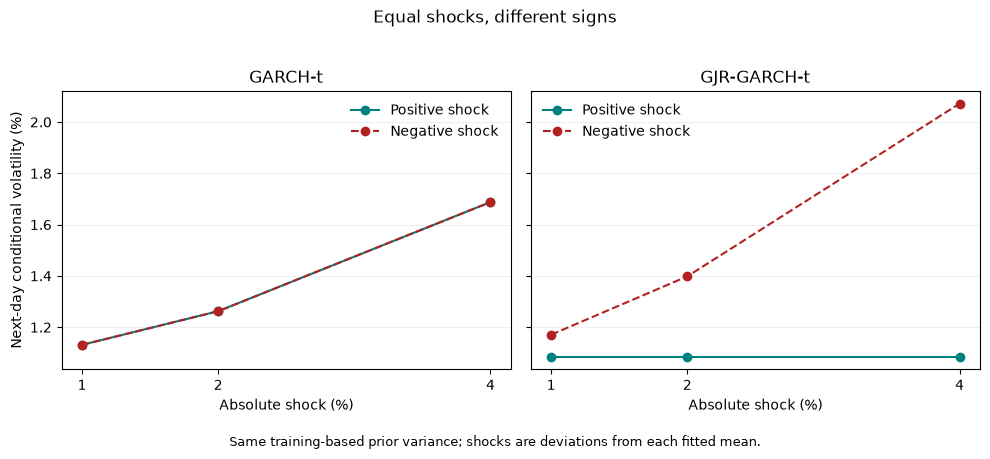

In [23]:
from left_tail.garch import next_variance, shock_table
from IPython.display import Image

shock_sizes_percent = np.array([1.0, 2.0, 4.0])
prior_variance = train_percent.var(ddof=0)
shock_responses = shock_table(fits, prior_variance)
display(shock_responses)
# Verify the symmetric model reacts equally to either sign.
np.testing.assert_allclose(
    next_variance(garch_t_fit.params, shock_sizes_percent, prior_variance),
    next_variance(garch_t_fit.params, -shock_sizes_percent, prior_variance),
)
# The extra negative-shock variance is gamma times shock squared.
np.testing.assert_allclose(
    next_variance(gjr_fit.params, -shock_sizes_percent, prior_variance)
    - next_variance(gjr_fit.params, shock_sizes_percent, prior_variance),
    gjr_fit.params["gamma[1]"] * shock_sizes_percent**2,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, name in zip(axes, ["GARCH-t", "GJR-GARCH-t"]):
    for sign, label, color in [(1, "Positive shock", "teal"), (-1, "Negative shock", "firebrick")]:
        response = np.sqrt(next_variance(fits[name].params, sign * shock_sizes_percent, prior_variance))
        ax.plot(shock_sizes_percent, response, marker="o", label=label, color=color,
                linestyle="-" if sign == 1 else "--")
    ax.set(title=name, xlabel="Absolute shock (%)", xticks=shock_sizes_percent)
    ax.grid(axis="y", alpha=.2)
    ax.legend(frameon=False)
axes[0].set_ylabel("Next-day conditional volatility (%)")
fig.suptitle("Equal shocks, different signs")
fig.text(.5, .01, "Same training-based prior variance; shocks are deviations from each fitted mean.",
         ha="center", fontsize=9)
fig.tight_layout(rect=(0, .05, 1, .95))
figure_dir = ROOT / "results/figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "notebook_shock_responses.png", dpi=220, bbox_inches="tight")
plt.show()

### 13. How much data did these fits use?

Let's assemble a small table: model, training observations, reserved test observations, parameter count, and optimizer status. Include the estimated mean and Student-t degrees of freedom in the parameter count.

Several thousand daily observations may be informative for a model with a few parameters. The raw count still leaves questions about dependence, changing market conditions, and how many extreme episodes the sample contains.

We can compare in-sample fit, but we haven't tested future forecasts. A fitted volatility path uses parameters estimated from the entire training period; it must not be reused as if those estimates were available at every earlier date.

**Interpretation:** parameter counts are 3, 4, 5, and 6 for these four specifications. Compare the computed sample sizes with those counts, while recognizing that serial dependence and changing regimes limit independent information. Lower AIC means a preferred fit under that in-sample criterion on comparable data; it does not demonstrate better future forecasts. GARCH conditions on information supplied to it. A genuinely unobserved future shock is not known in advance.

In [24]:
model_table = pd.DataFrame([
    {"model": name, "total returns": len(spy_returns), "training observations": int(fit.nobs),
     "reserved test observations": len(reserved_test), "estimated parameters": len(fit.params),
     "persistence": persistence(fit.params), "in-sample AIC": fit.aic,
     "convergence flag": int(fit.convergence_flag)}
    for name, fit in fits.items()
]).set_index("model")
parameter_table = pd.DataFrame({name: fit.params for name, fit in fits.items()}).T
display(model_table)
display(parameter_table)
display(pd.DataFrame(fit_diagnostics))
table_dir = ROOT / "results/tables"
table_dir.mkdir(parents=True, exist_ok=True)
model_table.to_csv(table_dir / "notebook_model_summary.csv")
parameter_table.to_csv(table_dir / "notebook_parameters.csv")
shock_responses.to_csv(table_dir / "notebook_shock_responses.csv", index=False)

,total returns,training observations,reserved test observations,estimated parameters,persistence,in-sample AIC,convergence flag
model,,,,,,,
ARCH(1),8463,6779,1684,3,0.398512,20178.558388,0
"GARCH(1,1)",8463,6779,1684,4,0.986106,18085.577437,0
GARCH-t,8463,6779,1684,5,0.997744,17739.438907,0
GJR-GARCH-t,8463,6779,1684,6,0.987360,17539.359291,0


,alpha[1],beta[1],gamma[1],mu,nu,omega
ARCH(1),0.398512,NaN,NaN,0.061325,NaN,0.846166
"GARCH(1,1)",0.108802,0.877304,NaN,0.074352,NaN,0.018170
GARCH-t,0.104585,0.893159,NaN,0.084305,5.871060,0.010431
GJR-GARCH-t,0.000000,0.890019,0.194683,0.059091,6.530412,0.015482


,model,convergence_flag,warnings,runtime_seconds
0,ARCH(1),0,[],0.053526
1,"GARCH(1,1)",0,[],0.044191
2,GARCH-t,0,[],0.077992
3,GJR-GARCH-t,0,[],0.087080


### 14. Check our work, then pause

As we implement the calculations, we'll check them against small examples and the tests in `tests/`. The supporting code already has tests we can read alongside our notebook versions.

By the end of Part 1, we want the data audit, four fitted models, the shock comparison, explanations of the parameters, passing tests, and an updated article and research log.

**Stop for review before Part 2.** The next research question will be how to connect these total-variance forecasts with our future downside target.

**Status:** the remaining code and answer notes are now filled in, but the newly completed cells have not been executed. The notebook is ready for our walkthrough, not yet a completed empirical milestone. We will review outputs and then update the article with findings; no model winner is claimed here.

In [25]:
import subprocess
# Runs the existing calculation tests only when you execute this cell.
test_run = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT,
                          capture_output=True, text=True)
print(test_run.stdout)
if test_run.stderr:
    print(test_run.stderr)
assert test_run.returncode == 0, "Resolve failing tests before completing Part 1."
print("Part 1 review checkpoint: inspect results together before Part 2.")

.....................                                                    [100%]
21 passed in 1.37s

Part 1 review checkpoint: inspect results together before Part 2.
